# Sagan Summer Workshop 2026: Hands On Session I - Answer Key
## Single-lens microlensing model fitting

Casey Lam (Carnegie), Ali Crisp (OSU), Scott Gaudi (OSU), Katarzyna Kruszynska (LCO), Amber Malpas (OSU),  Arjun Mulidhar (OSU), Himanshu Verma(LSU)

Thanks to Radek Poleski (University of Warsaw, Poland) and Meet Vyas (University of Vienna) for testing and helpful feedback on this notebook.

Prior to running this notebook, be sure to run the setup notebook:  SSW2026_I_Microlens_Setup.ipynb. The setup notebook just needs to be run **once**.

# ANSWER KEY
For now, this notebook contains all the answers. A separate notebook will be made for the hands-on session that does not contain the answers. To do this we will comment out certain lines. For lines to be commented out, search in the code ``#FILL IN LIVE``

## Google Colab Usage

**Confirm login account**
* Please make sure to be logged in with the Google account you want to use for the exercises before running the code cells below. You can check by clicking the circular account icon in the top right corner of the colab notebook.

**Working directory**
* Note: The software and data will be installed in a directory called "SSW2026/Microlens" in your Google drive. This directory will be created if it does not exist.

**Running cells**
* Run cells individually by clicking on the triangle on each cell
* For text cells, you can click the down arrow to get to the next cell

**To Restart runtime**
*   Click on Runtime menu item
*   Select Restart session
*   Select Run code cells individually from the top

**To Recreate runtime**
*   Click on Runtime menu item
*   Select Disconnect and Delete runtime
*   Select Run code cells individually from the top

**To Exit:**
*   Close the browser window

# Installation of corner
corner is a python package to make corner plots.
Installation instructions are found here: https://corner.readthedocs.io/en/latest/install/

# Installation of emcee
emcee is a python package to perform MCMC sampling.
Installation instructions are found here: https://emcee.readthedocs.io/en/stable/user/install/

The emcee paper (Foreman-Mackey et al. 2013) contains some additional background and references: https://ui.adsabs.harvard.edu/abs/2013PASP..125..306F/abstract

# Installation of MuLensModel
### *The MulensModel software has downloaded by the setup notebook as a reference for the source, but this notebook uses a  pip install.*

These are instructions on how to install MuLensModel (https://github.com/rpoleski/MulensModel/), the package we will use in Hands On Session I to fit microlensing events. These instructions can be updated/generalized to wherever IPAC will be setting up the materials.

The source code is here: https://github.com/rpoleski/MulensModel/releases/tag/v3.9.0

The installation instructions are here: https://rpoleski.github.io/MulensModel/install.html


### ❗ Run the next **2** cells to install the software. ❗

In [ ]:
# COLAB-ONLY
%pip install --quiet VBMicrolensing emcee corner multiprocess MulensModel ipympl

# Colab widget bug work-around
get_ipython().kernel.do_shutdown(restart=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 20.9 MB/s eta 0:00:00


{'status': 'ok', 'restart': True}

###❗ **Restart session** ❗
You may need to restart the session - this was likely already done - you may have seen a runtime has crashed message which was the auto restart. If not, you can do a manual restart  (dropdown menu next to "Run all" button) After you restart the session, don't re-run the above cells, just continue with the next cell.

In [ ]:
# COLAB-ONLY
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
# You will be prompted to Permit this notebook to access your Google Drive files - Click on "Connect to Google Drive"
# You will then be prompted to Choose an account - click on your preferred Google account
# You will then confirm that Google Drive for desktop wants to access your Google Account - select all and scroll to click "Continue"
# You may get another prompt to allow additional access for this to work - scroll to click "Continue"

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Set directory again after restart sesson
# Note - this directory was created by the setup notebook but defined in
# this notebook so the files can be found by this notebook

ssw_dir = 'SSW2026/Microlens' #@param {type:"string"}


In [ ]:
# Set directory again after restart session
# Change directory
# change to the MulensModel Directory
import os
import sys

# Google top level drive dir
drive_dir = "/content/drive/MyDrive/"

# SSW dir path
ssw_path = os.path.join(drive_dir, ssw_dir)

# pointlensdata path
pointlensdata_path = os.path.join(ssw_path, 'pointlensdata')


That should be it. **You may need to restart the session (dropdown menu next to "Run all" button) to actually get MulensModel to import.** After you restart the session, don't re-run the above cells, just continue with the next cell.

# An intro to MulensModel

We'll start with a introduction to MulensModel. It is based on https://github.com/rpoleski/MulensModel/blob/master/examples/MulensModelTutorial.ipynb




In [ ]:
import MulensModel as mm
import emcee
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.optimize as op
import pandas as pd
import corner

Mulens has many different modules. The primary three modules you will interact with in this workshop are `Model`, `MulensData`, and `Event`.

# `Model`

`Model` defines a microlensing model. To instantiate a `Model` object requires passing in a dictionary of microlensing model parameters.
Full documentation is at https://rpoleski.github.io/MulensModel/MulensModel.model.html#module-MulensModel.model

As a first example, we instantiate three different `Model` objects.
These are both point-source point-lens models (PSPL), which is the simplest possible microlensing model.
As the name suggests, this assumes that the foreground object doing the lensing is a point mass, and the background source of light being lensed is also a point source.
This model also assumes that the lens and source are moving at constant velocity with respect to the observer (i.e., no acceleration).

For the PSPL model, we choose different values for the parameters (`t_0` = time of minimum source-lens projected separation in days, `u_0` = minimum source-lens projected separation in units of the Einstein radius, `t_E` = Einstein crossing time in days).


In [ ]:
my_pspl_model_1 = mm.Model({'t_0': 2452886.06, 'u_0': 0.133, 't_E': 61.5})

my_pspl_model_2 = mm.Model({'t_0': 2452838.06, 'u_0': 0.08, 't_E': 26})

my_pspl_model_3 = mm.Model({'t_0': 2452838.06, 'u_0': 0.08, 't_E': 61.5})

Once a `Model` object has been instantiated, we can call their methods.
One useful one is `plot_magnification`, which can be used to create a lightcurve with the parameters that defined the model.

Below we can see that:
- `my_pspl_model_1`, which has a larger `t_0` than `my_pspl_model_2` and `my_pspl_model_3`, peaks in magnification later,
- `my_pspl_model_1`, which has a larger `u_0` than `my_pspl_model_2` and `my_pspl_model_3`, has a lower peak magnification, and
- `my_pspl_model_3`, which has a larger `t_E` than `my_pspl_model_2`, has a wider lightcurve.

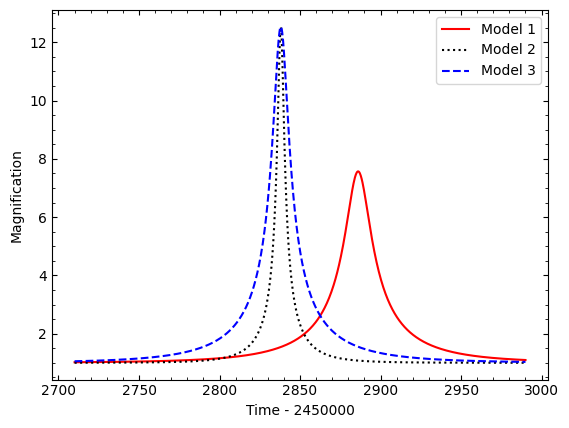

In [ ]:
my_pspl_model_1.plot_magnification(
    t_range=[2452810-100, 2452890+100], subtract_2450000=True, color='red',
    label='Model 1')
my_pspl_model_2.plot_magnification(
    t_range=[2452810-100, 2452890+100], subtract_2450000=True, color='k',
    ls=':', label='Model 2')
my_pspl_model_3.plot_magnification(
    t_range=[2452810-100, 2452890+100], subtract_2450000=True, color='blue',
    ls='--', label='Model 3')
plt.legend(loc='best')
plt.show()

Below are more complex examples to illustrate modeling of higher-order effects. "Higher-order effects" is a catch-all description for anything that violates the assumptions made in the PSPL model. Higher-order effects are of particular interest because they provide ways to measure or constrain the mass of the lens.

The first higher effect we'll consider are finite-source effects. This is when the assumption of the source being a point is broken. Below are two example light curves, with (FSPL) and without (PSPL) finite source effects. In this first example at low magnification, the lightcurves look identical.

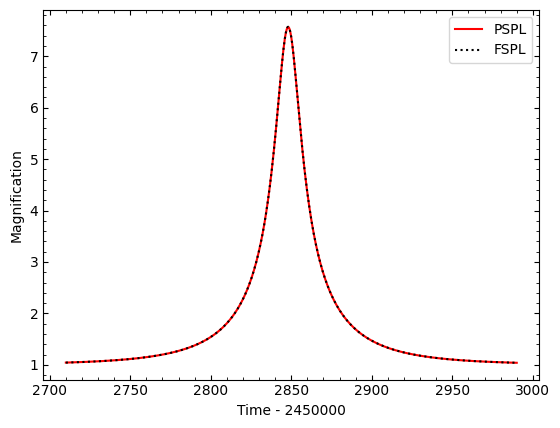

In [ ]:
# The simplest thing is a point-source point-lens model.
my_pspl_model = mm.Model({'t_0': 2452848.06, 'u_0': 0.133, 't_E': 61.5})

# Finite source point-lens model. Note they are instantiated in the same way,
# the only difference is you add more parameters (in this case, rho).
my_fspl_model = mm.Model(
    {'t_0': 2452848.06, 'u_0': 0.133, 't_E': 61.5, 'rho': 0.0096})

# Since rho is set, define a time range and approximation method to apply
# finite source effects.
t_0 = 2452848.06
my_fspl_model.set_magnification_methods([t_0 - 5.,
                                         'finite_source_uniform_Gould94',
                                         t_0 + 5.])

# Plot those models:
my_pspl_model.plot_magnification(
    t_range=[2452810-100, 2452890+100], subtract_2450000=True, color='red',
    label='PSPL')
my_fspl_model.plot_magnification(
    t_range=[2452810-100, 2452890+100], subtract_2450000=True, color='black',
    linestyle=':', label='FSPL')
plt.legend(loc='best')
plt.show()

However, at high magnification, the rounded-over look of the FSPL lightcurve is clearly seen. The maximum magnification of the FSPL lightcurve is also lower than that of the PSPL lightcurve.

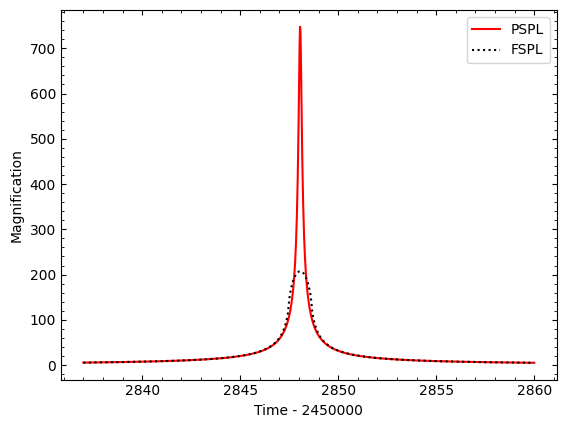

In [ ]:
# The simplest thing is a point-source point-lens model.
my_pspl_model = mm.Model({'t_0': 2452848.06, 'u_0': 0.00133, 't_E': 61.5})

# Finite source point-lens model. Note they are instantiated in the same way,
# the only difference is you add more parameters.
my_fspl_model = mm.Model(
    {'t_0': 2452848.06, 'u_0': 0.00133, 't_E': 61.5, 'rho': 0.0096})

# Since rho is set, define a time range and method to apply
# finite source effects:
t_0 = 2452848.06
my_fspl_model.set_magnification_methods([t_0 - 5.,
                                         'finite_source_uniform_Gould94',
                                         t_0 + 5.])

# Plot those models:
my_pspl_model.plot_magnification(
    t_range=[2452810+27, 2452890-30], subtract_2450000=True, color='red',
    label='PSPL')
my_fspl_model.plot_magnification(
    t_range=[2452810+27, 2452890-30], subtract_2450000=True, color='black',
    linestyle=':', label='FSPL')
plt.legend(loc='best')
plt.show()

Next, we consider the effect of annual parallax. This is when the assumption of rectilinear motion is broken, due to Earth's orbit around the Sun. For a short timescale events (e.g., a few days), this effect can be ignored because Earth's velocity is approximately constant. But for a longer event (e.g., a few months), it can become detectable. This effect typically manifests as a slightly asymmetric looking lightcurve.

Recall the definition of the microlensing parallax vector $\vec{\pi}_E = \frac{\pi_L - \pi_S}{\theta_E} \hat{\mu}_{rel}$.
The magnitude of $\vec{\pi}_E$ is defined to be the relative parallax of the source and lens $\pi_L - \pi_S$ in units of the Einstein radius $\theta_E$, and the direction of the parallax vector is defined to be parallel to the direction of the source-lens relative proper motion $\mu_{rel}$.

There are many different possible conventions used in modeling microlensing parallax. One that is commonly used is to choose a reference time `t_0_par` from which an accelerating frame is defined, and to break the parallax vector in its north and east components `pi_E_E` and `pi_E_N`.

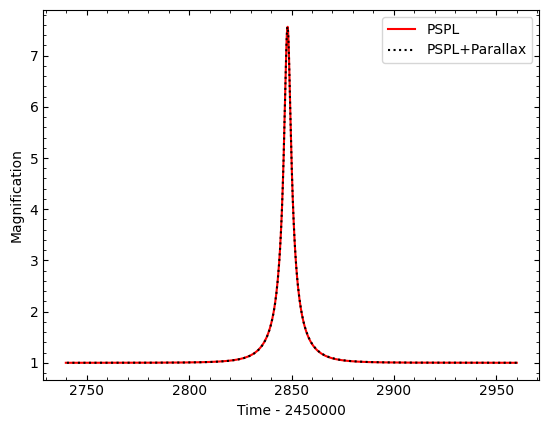

In [ ]:
# The simplest thing is a point-source point-lens model.
my_pspl_model = mm.Model({'t_0': 2452848.06, 'u_0': 0.133, 't_E': 12.5})

# Point-source point-lens model with parallax. Again, this is instantiated the
# same way as the PSPL model, but there are more parameters.
# Note we need coordinates in a parallax model, because the effect is dependent
# on the position of the object relative to the Sun.
coords = "17:52:41 -29:16:46"
my_parallax_model = mm.Model({'t_0': 2452848.06, 'u_0': 0.133, 't_E': 12.5,
                              'pi_E_N' : 0.1, 'pi_E_E' : -0.5}, coords=coords)

# Plot those models:
my_pspl_model.plot_magnification(
    t_range=[2452810+150, 2452890-150], subtract_2450000=True, color='red',
    label='PSPL')
my_parallax_model.plot_magnification(
    t_range=[2452810+150, 2452890-150], subtract_2450000=True, color='black',
    linestyle=':', label='PSPL+Parallax')
plt.legend(loc='best')
plt.show()

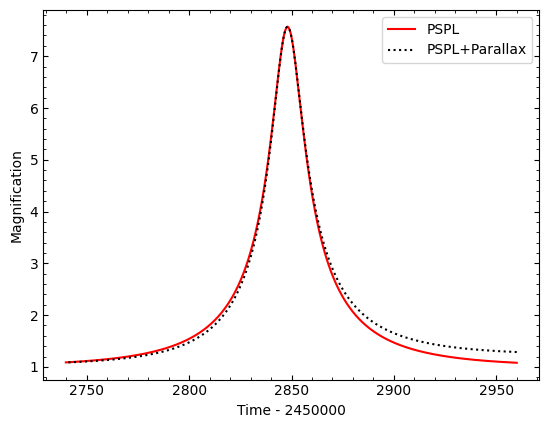

In [ ]:
# The simplest thing is a point-source point-lens model.
my_pspl_model = mm.Model({'t_0': 2452848.06, 'u_0': 0.133, 't_E': 61.5})

# Point-source point-lens model with parallax. Again, this is instantiated the
# same way as the PSPL model, but there are more parameters.
# Note we need coordinates in a parallax model, because the effect is dependent
# on the position of the object relative to the Sun.
coords = "17:52:41 -29:16:46"
my_parallax_model = mm.Model({'t_0': 2452848.06, 'u_0': 0.133, 't_E': 61.5,
                              'pi_E_N' : 0.1, 'pi_E_E' : -0.5}, coords=coords)

# Plot those models:
my_pspl_model.plot_magnification(
    t_range=[2452810+150, 2452890-150], subtract_2450000=True, color='red',
    label='PSPL')
my_parallax_model.plot_magnification(
    t_range=[2452810+150, 2452890-150], subtract_2450000=True, color='black',
    linestyle=':', label='PSPL+Parallax')
plt.legend(loc='best')
plt.show()

# `MulensData`

The `MulensData` object holds discrete lightcurve data: time, magnitude or flux, and its uncertainty (in that order).

Full documentation at https://rpoleski.github.io/MulensModel/MulensModel.mulensdata.html#module-MulensModel.mulensdata

Below, we instantiate two `MulensData` objects with simulated Roman data:

In [ ]:
data1 = mm.MulensData(file_name=pointlensdata_path + "/pspl.csv", skiprows=1, delimiter=',', phot_fmt='mag')
data2 = mm.MulensData(file_name=pointlensdata_path + "/fspl.csv", skiprows=1, delimiter=',', phot_fmt='mag')

# If your data is in arrays, can also format it this way:
# data = mm.MulensData(data_list=[[Dates], [Magnitudes], [Errors]], phot_fmt='flux')

With the `MulensData` object instantiated, we can call their methods. We can use `plot` to examine the data.

We can see that they have similar baseline (unmagnified) magnitudes, but the lightcurve shapes look very different: Dataset 1 looks like a regular PSPL event, but Dataset 2 exhibits strong finite-source effects (the round-topped lightcurve).

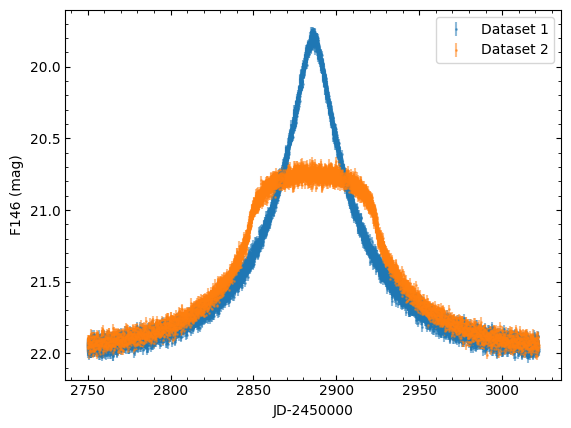

In [ ]:
data1.plot(show_errorbars=True, subtract_2450000=True, ms=1, alpha=0.5, label='Dataset 1')
data2.plot(show_errorbars=True, subtract_2450000=True, ms=1, alpha=0.5, label='Dataset 2')
plt.ylabel('F146 (mag)')
plt.xlabel('JD-2450000')
plt.legend()
plt.show()

# `Event`

Finally, the `Event` object takes a `Model` object and a `MulensData` object and links them together. This is useful because it enables the calculation of the $\chi^2$ goodness of fit statistic.

Full documentation is at https://rpoleski.github.io/MulensModel/MulensModel.event.html#module-MulensModel.event

We can instantiate an `Event` object using the `Model` and `MulensData` objects we created earlier:

In [ ]:
my_event = mm.Event(datasets=[data1], model=my_pspl_model_1)

By holding the data and model together, the `Event` object enables you to compare them.

To do a visual comparison, you can call `plot_data` and `plot_model`:

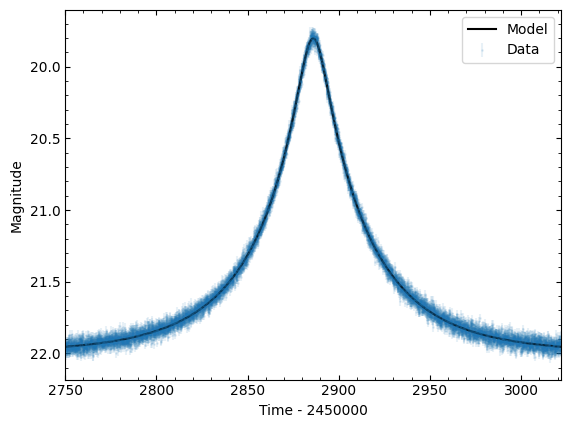

In [ ]:
my_event.plot_data(subtract_2450000=True, ms=1, alpha=0.1, label='Data')
my_event.plot_model(t_range=[2452750, 2453100], subtract_2450000=True,
    color='black', label='Model')
plt.legend()
plt.show()

We can use several of the `Event` methods to calculate the goodness-of-fit statistic and evaluate how well the model explains the data.

In [ ]:
chi2 = my_event.get_chi2()

# Number of degrees of freedom: # data points - # free parameters
Ndof = my_event.datasets[0].n_epochs - 5

# z-score (since Ndof >> 50, the chi2 distribution is nearly identical to a
# normal distribution)
z = (chi2 - Ndof)/np.sqrt(2*Ndof)

print('chi2 : {0:.2f}'.format(chi2))
print('Number of degrees of freedom : ', Ndof)
print('z-score : {0:.2f}'.format(z))

chi2 : 7049.76
Number of degrees of freedom :  6907
z-score : 1.21


A small aside: if you are paying very careful attention, you'll notice that although the data was given in magnitudes, the model was given in magnification: how is the magnification model getting converted into magnitudes?

Under the hood, `get_chi2` is calling the `FitData` module. Somewhat confusingly, `FitData` does NOT fit for any of the geometric microlensing parameters (`t_0`, `t_E`, `u_0`). Rather, it only fits for amount of blending, i.e. the source and blend fluxes/magnitudes, given the magnification model.

If this isn't immediately obvious or clear, don't worry about it for now. Just know that although there exists a module called `FitData`, it is not actually used for fitting data with the exception of blending!

# Fitting Lightcurves
MulensModel is used to generate the lightcurves, and provides functionality to compare models to data. However, it does not actually perform model fitting, which entails finding the model that best explains the data (i.e., minimize the difference between model and data).

Although MulensModel does not provide a specific method to perform model fitting, you can choose and implement your own. We'll do an example here using both $\chi^2$ minimization and MCMC. There are other fitting methodologies (e.g., nested sampling) which we do not explore here.

We re-emphasize here that the mulensdata `FitData` module does NOT fit for any of the geometric microlensing parameters! It only fits for blending.

<!-- Here, we will demonstrate fitting lightcurves with increasing amounts of complexity (parallax, finite-source effects). These complexities are always present, but the question is whether or not they aren necessary to model (e.g., for the purposes of building a bridge, you can ignore the effects of general relativity, but if you're trying to calculate positions with GPS, you cannot). -->

## Fitting a PSPL event with $\chi^2$ minimization

We start with the simplest possible model and the simplest possible fitting scheme, which is $\chi^2$ minimization. We will use scipy.optimize to perform the minimization. To do that, we need to define an objective function (i.e., the quantity we are trying to minimize):

In [ ]:
# This is from https://github.com/rpoleski/MulensModel/blob/master/examples/example_02_fitting.py
# scipy.optimize uses the Nelder-Mead minimization method.
def chi2_fun(theta, parameters_to_fit, event):
    """
    Calculate chi2 for given values of parameters.

    Keywords :
        theta: *np.ndarray*
            Vector of parameter values, e.g.,
            `np.array([5380., 0.5, 20.])`.

        parameters_to_fit: *list* of *str*
            List of names of parameters corresponding to theta, e.g.,
            `['t_0', 'u_0', 't_E']`.

        event: *MulensModel.Event*
            Event which has datasets for which chi2 will be calculated.

    Returns :
        chi2: *float*
            Chi2 value for given model parameters.
    """
    # First we have to change the values of parameters in
    # event.model.parameters to values given by theta.
    for (parameter, value) in zip(parameters_to_fit, theta):
        setattr(event.model.parameters, parameter, value)

    # After that, calculating chi2 is trivial:
    return event.get_chi2()

First, we load in the data, create a MulensModel object, and use that to visualize the data.

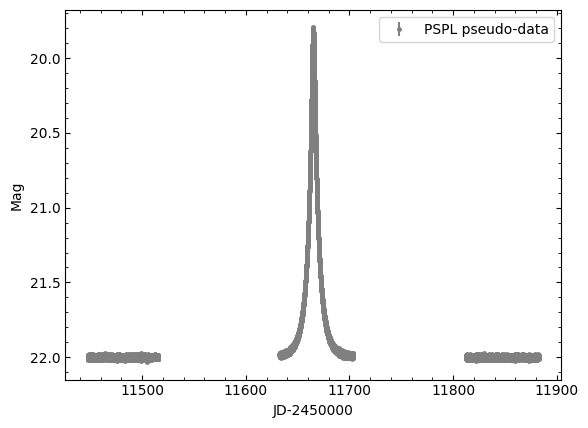

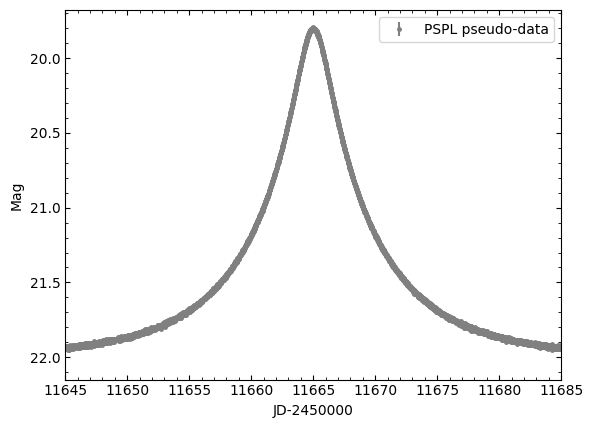

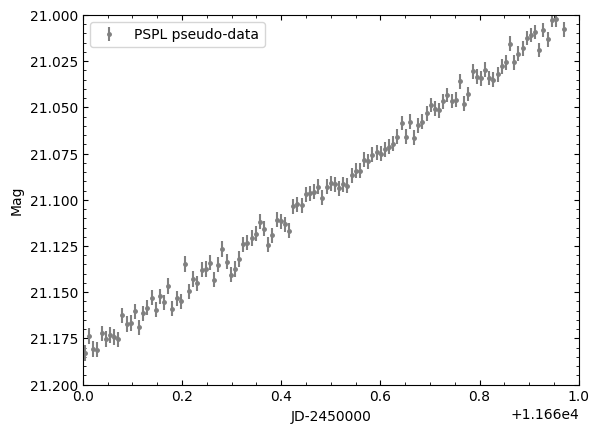

In [ ]:
# Load data, and then use it to instantiate a MulensData object.
pspl_data = pd.read_csv(pointlensdata_path + "/example9.csv")

pspl_mudata = mm.MulensData(data_list=[pspl_data['time'], pspl_data['magF146'], pspl_data['magF146err']]) #FILL IN LIVE

# Plot the full lightcurve.
plt.figure()
pspl_mudata.plot(subtract_2450000=True, label='PSPL pseudo-data', color='gray', marker='.', linestyle='None') #FILL IN LIVE
plt.legend()
plt.ylabel('Mag')
plt.xlabel('JD-2450000')
plt.show()

# Zoom in, to see how small the error bars are...
plt.figure()
pspl_mudata.plot(subtract_2450000=True, label='PSPL pseudo-data', color='gray', marker='.', linestyle='None') #FILL IN LIVE
plt.legend()
plt.ylabel('Mag')
plt.xlabel('JD-2450000')
plt.xlim(11645, 11685)
plt.show()

# Zoom in to just the middle season.
plt.figure()
pspl_mudata.plot(subtract_2450000=True, label='PSPL pseudo-data', color='gray', marker='.', linestyle='None') #FILL IN LIVE
plt.legend()
plt.ylabel('Mag')
plt.xlabel('JD-2450000')
plt.xlim(11660, 11661)
plt.ylim(21.2, 21.0)
plt.show()

Next, let's try to fit it. We need to provide a starting guess for our $\chi^2$ minimization.

For t_0, a good guess is the time of peak magnification.
<!--, so we'll try 2452886. -->
For u_0, we can estimate it from the magnification equation assuming there is no blending. Recall the maximum magnification $A_{max} = \frac{u_0^2 + 2}{u_0\sqrt{u_0^2 + 4}}$.
<!-- Since this target brightened by about 2.5 mag, or a factor of 10, which corresponds to u0 = 0.1 -->
For t_E, a good guess is the full-width half-maximum of the lightcurve (also assuming no blending).
<!-- which is about 50 days for this light curve. -->

In [ ]:
parameters_to_fit = ["t_0", "u_0", "t_E"]
# Approximate values of the parameters are needed:
t_0 = 2450000 + 11665. #FILL IN LIVE
u_0 = 0.1 #FILL IN LIVE
t_E = 12. #FILL IN LIVE
model = mm.Model({'t_0': t_0, 'u_0': u_0, 't_E': t_E}) #FILL IN LIVE

Now, let's take this fit and try to do the optimization.

In [ ]:
# Link the data and the model
event = mm.Event(datasets=pspl_mudata, model=model) #FILL IN LIVE
print('Initial Trial\n{0}'.format(event.model.parameters))

# Find the best-fit parameters by using scipy optimize.
initial_guess = [t_0, u_0, t_E]
result = op.minimize(
    chi2_fun, x0=initial_guess, args=(parameters_to_fit, event),
    method='Nelder-Mead')
print(result.x)
(fit_t_0, fit_u_0, fit_t_E) = result.x

# Save the best-fit parameters
chi2 = chi2_fun(result.x, parameters_to_fit, event)

# Output the fit parameters
msg = 'Best Fit: t_0 = {0:12.5f}, u_0 = {1:6.4f}, t_E = {2:8.3f}'
print(msg.format(fit_t_0, fit_u_0, fit_t_E))
print('Chi2 = {0:12.2f}'.format(chi2))
print('scipy.optimize.minimize result:')
print(result)


Initial Trial
    t_0 (HJD)       u_0    t_E (d) 
2461665.00000  0.100000    12.0000 
[2.46166500e+06 1.33152795e-01 9.99318998e+00]
Best Fit: t_0 = 2461665.00008, u_0 = 0.1332, t_E =    9.993
Chi2 =     25197.48
scipy.optimize.minimize result:
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 25197.484933482814
             x: [ 2.462e+06  1.332e-01  9.993e+00]
           nit: 104
          nfev: 201
 final_simplex: (array([[ 2.462e+06,  1.332e-01,  9.993e+00],
                       [ 2.462e+06,  1.332e-01,  9.993e+00],
                       [ 2.462e+06,  1.332e-01,  9.993e+00],
                       [ 2.462e+06,  1.332e-01,  9.993e+00]]), array([ 2.520e+04,  2.520e+04,  2.520e+04,  2.520e+04]))


In [ ]:
# Number of degrees of freedom: # data points - # free parameters
Ndof = event.datasets[0].n_epochs - 5

# z-score
z = (chi2 - Ndof)/np.sqrt(2*Ndof)

print('chi2 : {0:.2f}'.format(chi2))
print('Number of degrees of freedom : ', Ndof)
print('z-score : {0:.2f}'.format(z))

chi2 : 25197.48
Number of degrees of freedom :  24869
z-score : 1.47


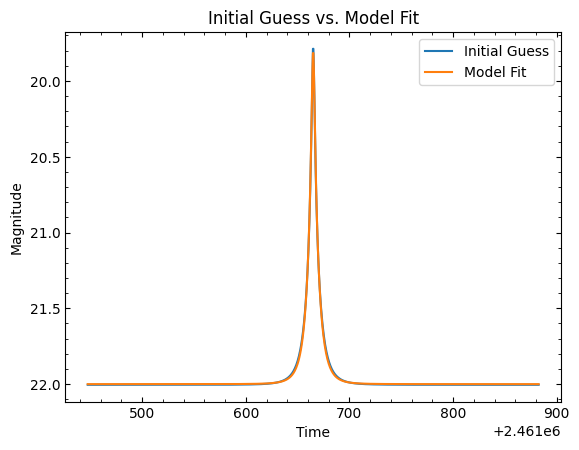

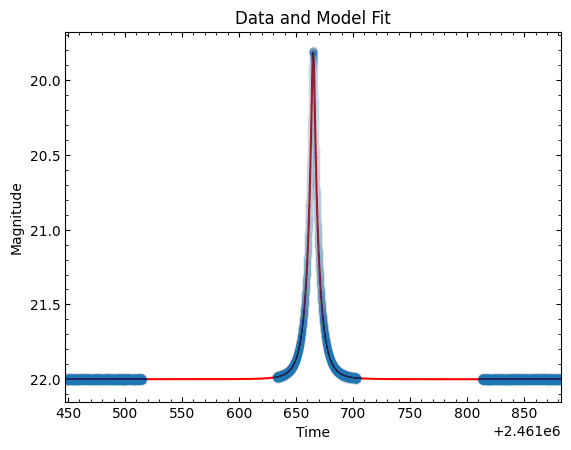

Original Parameters: t_0 =2461665.00, u_0=0.100, t_E=12.00 days
Fitted Parameters: t0=2461665.00, u_0=0.133, tE=9.99 days
Truth: t_0=2461665, u_0=0.133, t_E=10 days


In [ ]:
# Plot and compare the two models
init_model = mm.Model({'t_0': t_0, 'u_0': u_0, 't_E': t_E})
final_model = mm.Model({'t_0': fit_t_0, 'u_0': fit_u_0, 't_E': fit_t_E})

init_fit = mm.FitData(dataset=pspl_mudata, model=init_model)
init_fit.fit_fluxes()
final_fit = mm.FitData(dataset=pspl_mudata, model=final_model)
final_fit.fit_fluxes()

plt.figure()
init_model.plot_lc(
    source_flux=init_fit.source_flux, blend_flux=init_fit.blend_flux,
    t_range=[pspl_mudata.time.min(), pspl_mudata.time.max()],
    label='Initial Guess')
final_model.plot_lc(
    source_flux=final_fit.source_flux, blend_flux=final_fit.blend_flux,
    t_range=[pspl_mudata.time.min(), pspl_mudata.time.max()],
    label='Model Fit')
plt.title('Initial Guess vs. Model Fit')
plt.legend(loc='best')

# Plot the fitted model with the data
plt.figure()
event.plot_model(color='red', t_range=[pspl_mudata.time.min(), pspl_mudata.time.max()])
event.plot_data(alpha=0.01)
plt.title('Data and Model Fit')
plt.show()

print('Original Parameters: t_0 =%.2f, u_0=%.3f, t_E=%.2f days'%(t_0, u_0, t_E))
print('Fitted Parameters: t0=%.2f, u_0=%.3f, tE=%.2f days'%(event.model.parameters.t_0, event.model.parameters.u_0, event.model.parameters.t_E))
print('Truth: t_0=2461665, u_0=0.133, t_E=10 days') #FILL IN LIVE


## Fitting a PSPL event with MCMC
Having uncertainties are important, and that isn't provided when we perform $\chi^2$ minimization.
Because MCMC samples a distribution, it is good for quantifying our uncertainties.

We'll re-do our example above, but now using emcee to do the fitting.

First, we need to define our likelihood, prior, and posterior functions. These are based on https://rpoleski.github.io/MulensModel/tutorial_fit_pi_E.html

In [ ]:
def ln_like(theta, event, parameters_to_fit):
    """
    Calculate the log-likelihood. For a Gaussian log-likelihood function, this
    is equal to -0.5 * chi2.
    """
    for (parameter, value) in zip(parameters_to_fit, theta):
        setattr(event.model.parameters, parameter, value)

    chi2 = event.get_chi2()

    if chi2 < ln_like.best[0]:
        # Functions can have attributes. We have an attribute called "best",
        # which contains the smallest chi2 and the corresponding parameters.
        ln_like.best = [chi2, theta]

    return -0.5 * chi2

# Create the "best" attribute.
ln_like.best = [np.inf]

def ln_prior(theta, parameters_to_fit, event):
    """
    Calculate the log-prior.
    t_E is not allowed to be negative,
    and we have a condition that disfavors negative blending (fs > 1).
    """
    for (parameter, value) in zip(parameters_to_fit, theta):
        setattr(event.model.parameters, parameter, value)

    # Calculate the amount of blending
    event.fit_fluxes()
    source_flux = event.source_fluxes[0]
    blend_flux = event.blend_fluxes[0]
    fs = source_flux/(source_flux + blend_flux)

    if theta[parameters_to_fit.index('t_E')] < 0.:
        return -np.inf

    if fs > 1:
         mean = 1.
         sigma = 0.1
         return -0.5 * ((fs - mean) / sigma)**2

    return 0.0

def ln_prob(theta, event, parameters_to_fit):
    """
    Calculate the log-posterior. Since the product of the prior and the likelihood
    is proportional to the posterior, the sum of the log-prior and the
    log-likelihood is proportional to the log-posterior
    """
    ln_prior_ = ln_prior(theta, parameters_to_fit, event)

    # Calculate the amount of blending
    event.fit_fluxes()
    source_flux = event.source_fluxes[0]
    blend_flux = event.blend_fluxes[0]
    fs = source_flux/(source_flux + blend_flux)

    if not np.isfinite(ln_prior_):
        return (-np.inf, fs)

    ln_like_ = ln_like(theta, event, parameters_to_fit)

    if np.isnan(ln_like_):
        return (-np.inf, fs)

    return (ln_prior_ + ln_like_, fs)

As before, we need an inital guess to start the optimization. In this case for MCMC, we also need some starting range to initialize the fit.

In [ ]:
# Approximate values of the parameters are needed:
t_0 = 2450000 + 11665 #FILL IN LIVE
u_0 = 0.1 #FILL IN LIVE
t_E = 12 #FILL IN LIVE

guess_params = [t_0, u_0, t_E]

# We also need a range from which the fit will start.
t_0_walker_sigma = 1e-8 #FILL IN LIVE
u_0_walker_sigma = 1e-4 #FILL IN LIVE
t_E_walker_sigma = 1e-4 #FILL IN LIVE

sigmas = [t_0_walker_sigma, u_0_walker_sigma, t_E_walker_sigma]

Next, we set up the emcee parameters.

In [ ]:
n_dim = len(parameters_to_fit)
n_walkers = 25 #FILL IN LIVE
n_steps = 500 # 2000 #FILL IN LIVE
n_burn = 250 # 1000 #FILL IN LIVE
thin=10 #FILL IN LIVE

# Start the walkers at the inital guess in a region defined by the sigmas chosen
# in the cell above.
start_1 = [p for p in guess_params]
start = [start_1 + np.random.randn(n_dim) * sigmas for i in range(n_walkers)]

Next, we create the Mulens event which provides the model to fit.

In [ ]:
init_model = mm.Model({'t_0': guess_params[0], 'u_0': guess_params[1], 't_E': guess_params[2]})
muevent = mm.Event(datasets=pspl_mudata, model=init_model)

geom_labels = list(init_model.parameters.as_dict().keys())
all_labels = geom_labels + ['fs']

Finally, we can run emcee.

In [ ]:
sampler = emcee.EnsembleSampler(n_walkers, n_dim, ln_prob, args=(muevent, geom_labels))
sampler.run_mcmc(start, n_steps, progress=True);

100%|██████████| 500/500 [05:39<00:00,  1.47it/s]


In [ ]:
# This is for the geometric parameters
geom_samples = sampler.get_chain()
flat_geom_samples = sampler.get_chain(discard=n_burn, thin=thin, flat=True)

# This is for the blending
blobs = sampler.get_blobs()
flat_blobs = sampler.get_blobs(discard=n_burn, thin=thin, flat=True)

samples = np.concatenate([geom_samples, blobs.reshape(blobs.shape[0], blobs.shape[1], 1)], axis=2)
flat_samples = np.concatenate([flat_geom_samples, flat_blobs.reshape(len(flat_blobs), 1)], axis=1)

Let's inspect the MCMC chains. We want to make sure that the chains have converged by the time burn in has ended.

Answer Key:
t_0=2461665.000000
u_0=0.133000
t_E=10.000000
fs=1.000000


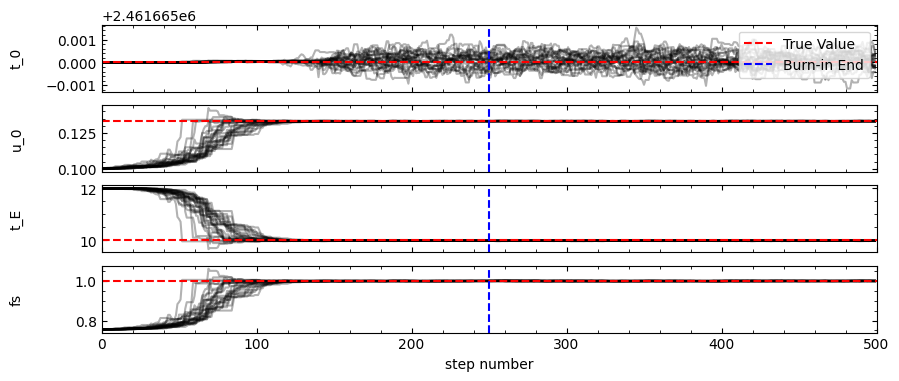

In [ ]:
truths = [2461665, 0.133, 10, 1] #FILL IN LIVE
print("Answer Key:") #FILL IN LIVE
print('\n'.join(['%s=%f'%(p, v) for p, v in zip(all_labels, truths)])) #FILL IN LIVE

fig, axes = plt.subplots(len(all_labels), 1, figsize=(10, len(all_labels)), sharex=True)
for i in range(len(all_labels)):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(all_labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.axhline(truths[i], color='red', linestyle='--', label='True Value') #FILL IN LIVE
    ax.axvline(n_burn, color='blue', linestyle='--', label='Burn-in End')
axes[-1].set_xlabel("step number");
axes[0].legend()
plt.show()

Let's plot a random subset of the models on top of the data to evaluate how the fit looks.

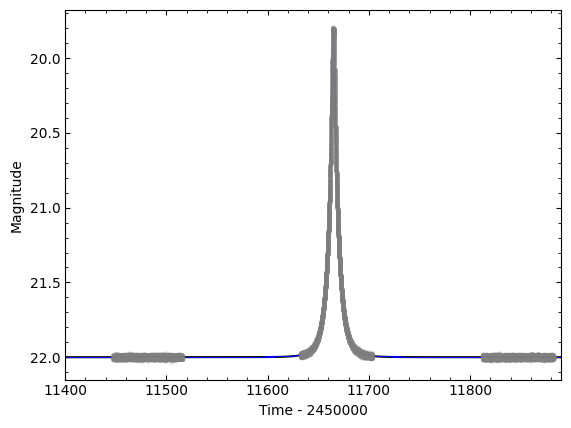

In [ ]:
inds = np.random.randint(len(flat_samples), size=100)
_true_mod = mm.Model({'t_0': truths[0], 'u_0': truths[1], 't_E': truths[2]}) #FILL IN LIVE
_event = mm.Event(datasets=pspl_mudata, model=_true_mod)
_event.plot_model(subtract_2450000=True, color='k', t_range=[2450000 + 11400, 2450000 + 11890])
for ind in inds:
    sample = flat_samples[ind]
    _mod = mm.Model({'t_0': sample[0], 'u_0': sample[1], 't_E': sample[2]})
    _event = mm.Event(datasets=pspl_mudata, model=_mod)
    _event.plot_model(subtract_2450000=True, color='b', t_range=[2450000 + 11400, 2450000 + 11890], lw=0.1)
_event.plot_data(subtract_2450000=True, color='gray', marker='.', linestyle='None', alpha=0.2)
plt.xlim(11400, 11890)
plt.show()

Finally, let's plot the posteriors.

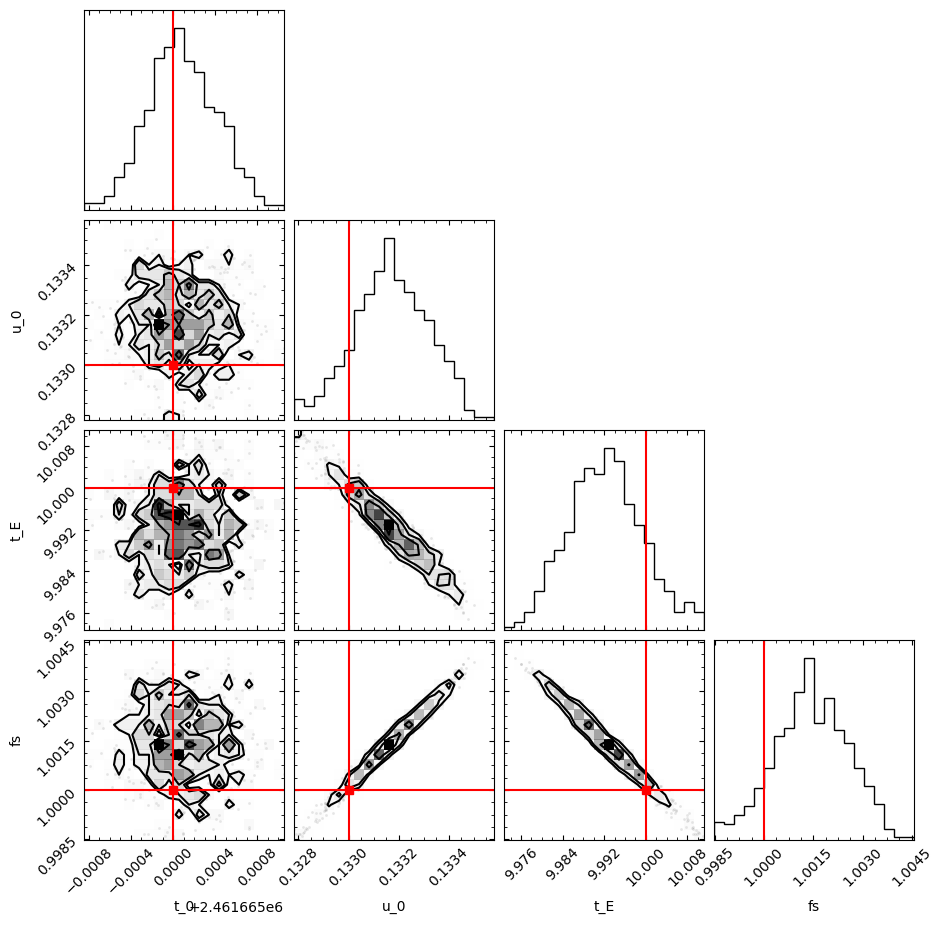

In [ ]:
fig = corner.corner(
    flat_samples,
    labels=all_labels,
    errorbar=True,
    truth_color="red", #FILL IN LIVE
    truths=truths #FILL IN LIVE
)
plt.show()

## Exploring the u0-tE-blending degeneracy
We'll do another PSPL example, but this time including blending, and use it to explore the concept of degeneracies in microlensing.

For the live demo during the Sagan Summer Workshop, we'll split the room into four: each will do one of the lightcurves and then we'll show the results all together on screen.


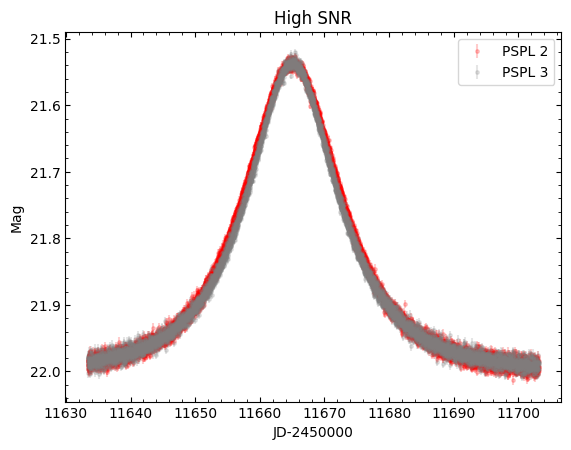

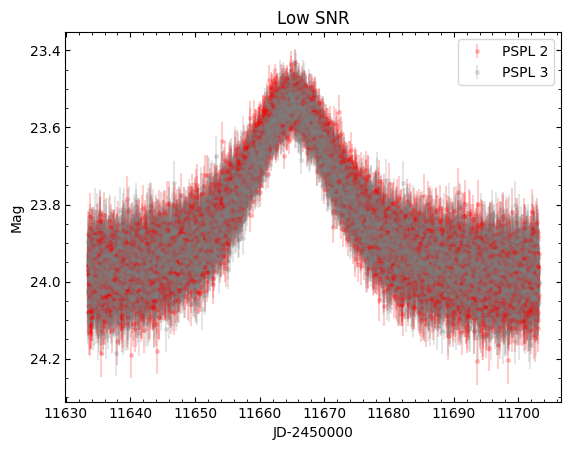

In [ ]:
# This is the higher SNR example
pspl_data2hi = pd.read_csv(pointlensdata_path + "/example17.csv")
pspl_data3hi = pd.read_csv(pointlensdata_path + "/example21.csv")

# This is the lower SNR example
pspl_data2lo = pd.read_csv(pointlensdata_path + "/example29.csv")
pspl_data3lo = pd.read_csv(pointlensdata_path + "/example33.csv")

pspl_mudata2hi = mm.MulensData(data_list=[pspl_data2hi['time'][8200:16500], pspl_data2hi['magF146'][8200:16500], pspl_data2hi['magF146err'][8200:16500]])
pspl_mudata3hi = mm.MulensData(data_list=[pspl_data3hi['time'][8200:16500], pspl_data3hi['magF146'][8200:16500], pspl_data3hi['magF146err'][8200:16500]])
pspl_mudata2lo = mm.MulensData(data_list=[pspl_data2lo['time'][8200:16500], pspl_data2lo['magF146'][8200:16500], pspl_data2lo['magF146err'][8200:16500]])
pspl_mudata3lo = mm.MulensData(data_list=[pspl_data3lo['time'][8200:16500], pspl_data3lo['magF146'][8200:16500], pspl_data3lo['magF146err'][8200:16500]])

# MulensModel has a very handy method for MulensData class
plt.figure()
pspl_mudata2hi.plot(subtract_2450000=True, label='PSPL 2', color='red', marker='.', linestyle='None', alpha=0.2)
pspl_mudata3hi.plot(subtract_2450000=True, label='PSPL 3', color='gray', marker='.', linestyle='None', alpha=0.2)
plt.legend()
plt.ylabel('Mag')
plt.xlabel('JD-2450000')
plt.title('High SNR')
plt.show()

plt.figure()
pspl_mudata2lo.plot(subtract_2450000=True, label='PSPL 2', color='red', marker='.', linestyle='None', alpha=0.2)
pspl_mudata3lo.plot(subtract_2450000=True, label='PSPL 3', color='gray', marker='.', linestyle='None', alpha=0.2)
plt.legend()
plt.ylabel('Mag')
plt.xlabel('JD-2450000')
plt.title('Low SNR')
plt.show()

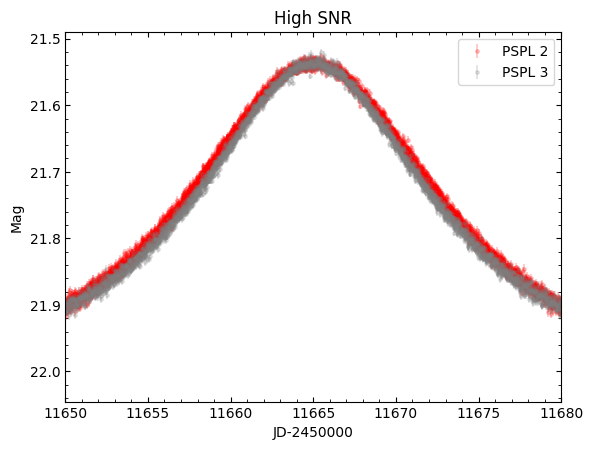

Answer Key (2):
t_0=2461665.000000
u_0=0.800000
t_E=10.000000
fs=1.000000
Answer Key (3):
t_0=2461665.000000
u_0=0.535000
t_E=12.500000
fs=0.500000


In [ ]:
# Zoom in so we can see where the maximum is more easily.
plt.figure()
pspl_mudata2hi.plot(subtract_2450000=True, label='PSPL 2', color='red', marker='.', linestyle='None', alpha=0.2)
pspl_mudata3hi.plot(subtract_2450000=True, label='PSPL 3', color='gray', marker='.', linestyle='None', alpha=0.2)
plt.legend()
plt.ylabel('Mag')
plt.xlabel('JD-2450000')
plt.title('High SNR')
plt.xlim(11650, 11680)
plt.show()

#build initial guess based on the data. Same guess as above.
t_0 = 2450000 + 11665.
u_0 = 0.3
t_E = 15.

guess_params = [t_0, u_0, t_E]

# initial model available for fitting
init_model_pspl = mm.Model({'t_0': guess_params[0], 'u_0': guess_params[1], 't_E': guess_params[2]})

muevent2hi = mm.Event(datasets=pspl_mudata2hi, model=init_model_pspl)
muevent3hi = mm.Event(datasets=pspl_mudata3hi, model=init_model_pspl)
muevent2lo = mm.Event(datasets=pspl_mudata2lo, model=init_model_pspl)
muevent3lo = mm.Event(datasets=pspl_mudata3lo, model=init_model_pspl)

truths2=[2461665, 0.8, 10, 1]
truths3=[2461665, 0.535, 12.5, 0.5]
geom_labels = list(init_model.parameters.as_dict().keys())
all_labels = geom_labels + ['fs']

print("Answer Key (2):")
print('\n'.join(['%s=%f'%(p, v) for p, v in zip(all_labels, truths2)]))


print("Answer Key (3):")
print('\n'.join(['%s=%f'%(p, v) for p, v in zip(all_labels, truths3)]))

In [ ]:
sigmas = [1e-8, 1e-4, 1e-4]

n_dim = len(parameters_to_fit)
n_walkers = 25
n_steps = 2000
n_burn = 1000
thin=10

start_1 = [p for p in guess_params]  # start near the initial fit
start = [start_1 + np.random.randn(n_dim) * sigmas for i in range(n_walkers)]

In [ ]:
# may take ~ 7 minutes to run
sampler2hi = emcee.EnsembleSampler(n_walkers, n_dim, ln_prob, args=(muevent2hi, parameters_to_fit))
sampler2hi.run_mcmc(start, n_steps, progress=True)

# This is for the geometric parameters
geom_samples2hi = sampler2hi.get_chain()
flat_geom_samples2hi = sampler2hi.get_chain(discard=n_burn, thin=thin, flat=True)

# This is for the blending
blobs2hi = sampler2hi.get_blobs()
flat_blobs2hi = sampler2hi.get_blobs(discard=n_burn, thin=thin, flat=True)

samples2hi = np.concatenate([geom_samples2hi, blobs2hi.reshape(blobs2hi.shape[0], blobs2hi.shape[1], 1)], axis=2)
flat_samples2hi = np.concatenate([flat_geom_samples2hi, flat_blobs2hi.reshape(len(flat_blobs2hi), 1)], axis=1)

100%|██████████| 2000/2000 [08:28<00:00,  3.94it/s]


In [ ]:
# may take ~ 7 minutes to run
sampler3hi = emcee.EnsembleSampler(n_walkers, n_dim, ln_prob, args=(muevent3hi, parameters_to_fit))
sampler3hi.run_mcmc(start, n_steps, progress=True)

# This is for the geometric parameters
geom_samples3hi = sampler3hi.get_chain()
flat_geom_samples3hi = sampler3hi.get_chain(discard=n_burn, thin=thin, flat=True)

# This is for the blending
blobs3hi = sampler3hi.get_blobs()
flat_blobs3hi = sampler3hi.get_blobs(discard=n_burn, thin=thin, flat=True)

samples3hi = np.concatenate([geom_samples3hi, blobs3hi.reshape(blobs3hi.shape[0], blobs3hi.shape[1], 1)], axis=2)
flat_samples3hi = np.concatenate([flat_geom_samples3hi, flat_blobs3hi.reshape(len(flat_blobs3hi), 1)], axis=1)

100%|██████████| 2000/2000 [08:19<00:00,  4.01it/s]


In [ ]:
# may take ~ 7 minutes to run
sampler2lo = emcee.EnsembleSampler(n_walkers, n_dim, ln_prob, args=(muevent2lo, parameters_to_fit))
sampler2lo.run_mcmc(start, n_steps, progress=True)

# This is for the geometric parameters
geom_samples2lo = sampler2lo.get_chain()
flat_geom_samples2lo = sampler2lo.get_chain(discard=n_burn, thin=thin, flat=True)

# This is for the blending
blobs2lo = sampler2lo.get_blobs()
flat_blobs2lo = sampler2lo.get_blobs(discard=n_burn, thin=thin, flat=True)

samples2lo = np.concatenate([geom_samples2lo, blobs2lo.reshape(blobs2lo.shape[0], blobs2lo.shape[1], 1)], axis=2)
flat_samples2lo = np.concatenate([flat_geom_samples2lo, flat_blobs2lo.reshape(len(flat_blobs2lo), 1)], axis=1)

100%|██████████| 2000/2000 [08:42<00:00,  3.83it/s]


In [ ]:
# may take ~ 7 minutes to run
sampler3lo = emcee.EnsembleSampler(n_walkers, n_dim, ln_prob, args=(muevent3lo, parameters_to_fit))
sampler3lo.run_mcmc(start, n_steps, progress=True)

# This is for the geometric parameters
geom_samples3lo = sampler3lo.get_chain()
flat_geom_samples3lo = sampler3lo.get_chain(discard=n_burn, thin=thin, flat=True)

# This is for the blending
blobs3lo = sampler3lo.get_blobs()
flat_blobs3lo = sampler3lo.get_blobs(discard=n_burn, thin=thin, flat=True)

samples3lo = np.concatenate([geom_samples3lo, blobs3lo.reshape(blobs3lo.shape[0], blobs3lo.shape[1], 1)], axis=2)
flat_samples3lo = np.concatenate([flat_geom_samples3lo, flat_blobs3lo.reshape(len(flat_blobs3lo), 1)], axis=1)

100%|██████████| 2000/2000 [08:10<00:00,  4.07it/s]


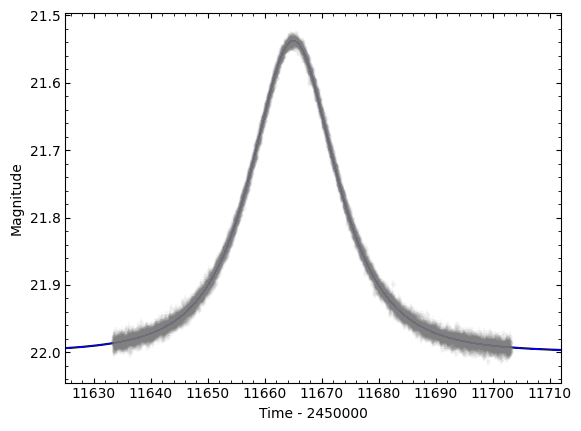

In [ ]:
inds = np.random.randint(len(flat_samples2hi), size=100)
_true_mod = mm.Model({'t_0': truths2[0], 'u_0': truths2[1], 't_E': truths2[2]}) #FILL IN LIVE
_event = mm.Event(datasets=pspl_mudata2hi, model=_true_mod)
_event.plot_model(subtract_2450000=True, color='k', t_range=[2450000 + 11400, 2450000 + 11890])
for ind in inds:
    sample = flat_samples2hi[ind]
    _mod = mm.Model({'t_0': sample[0], 'u_0': sample[1], 't_E': sample[2]})
    _event = mm.Event(datasets=pspl_mudata2hi, model=_mod)
    _event.plot_model(subtract_2450000=True, color='b', t_range=[2450000 + 11400, 2450000 + 11890], lw=0.1)
_event.plot_data(subtract_2450000=True, color='gray', marker='.', linestyle='None', alpha=0.05)
plt.xlim(11625, 11712)
plt.show()

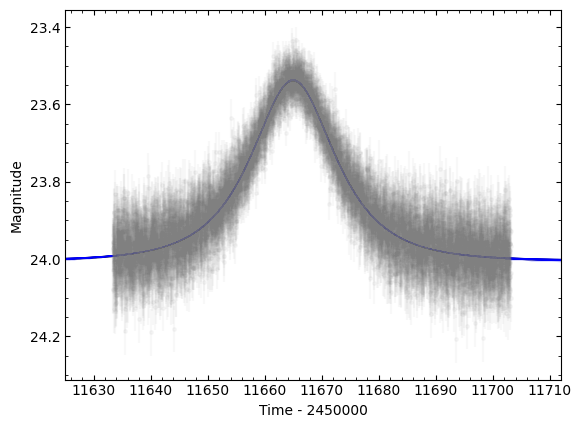

In [ ]:
inds = np.random.randint(len(flat_samples2lo), size=100)
_true_mod = mm.Model({'t_0': truths2[0], 'u_0': truths2[1], 't_E': truths2[2]}) #FILL IN LIVE
_event = mm.Event(datasets=pspl_mudata2lo, model=_true_mod)
_event.plot_model(subtract_2450000=True, color='k', t_range=[2450000 + 11400, 2450000 + 11890])
for ind in inds:
    sample = flat_samples2lo[ind]
    _mod = mm.Model({'t_0': sample[0], 'u_0': sample[1], 't_E': sample[2]})
    _event = mm.Event(datasets=pspl_mudata2lo, model=_mod)
    _event.plot_model(subtract_2450000=True, color='b', t_range=[2450000 + 11400, 2450000 + 11890], lw=0.1)
_event.plot_data(subtract_2450000=True, color='gray', marker='.', linestyle='None', alpha=0.05)
plt.xlim(11625, 11712)
plt.show()

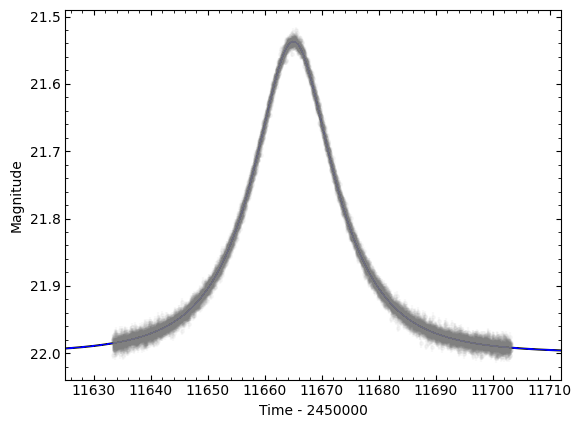

In [ ]:
inds = np.random.randint(len(flat_samples3hi), size=100)
_true_mod = mm.Model({'t_0': truths3[0], 'u_0': truths3[1], 't_E': truths3[2]}) #FILL IN LIVE
_event = mm.Event(datasets=pspl_mudata3hi, model=_true_mod)
_event.plot_model(subtract_2450000=True, color='k', t_range=[2450000 + 11400, 2450000 + 11890])
for ind in inds:
    sample = flat_samples3hi[ind]
    _mod = mm.Model({'t_0': sample[0], 'u_0': sample[1], 't_E': sample[2]})
    _event = mm.Event(datasets=pspl_mudata3hi, model=_mod)
    _event.plot_model(subtract_2450000=True, color='b', t_range=[2450000 + 11400, 2450000 + 11890], lw=0.1)
_event.plot_data(subtract_2450000=True, color='gray', marker='.', linestyle='None', alpha=0.05)
plt.xlim(11625, 11712)
plt.show()

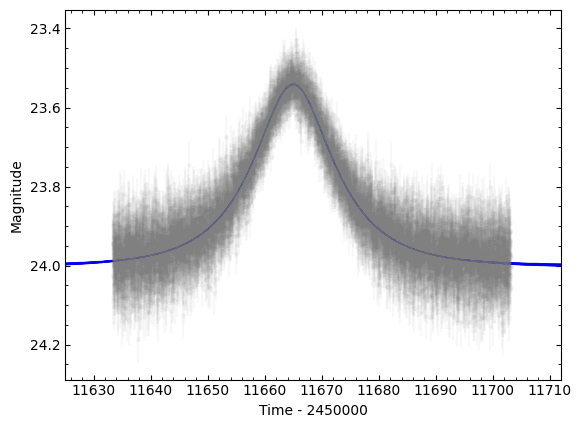

In [ ]:
inds = np.random.randint(len(flat_samples3lo), size=100)
_true_mod = mm.Model({'t_0': truths3[0], 'u_0': truths3[1], 't_E': truths3[2]}) #FILL IN LIVE
_event = mm.Event(datasets=pspl_mudata3lo, model=_true_mod)
_event.plot_model(subtract_2450000=True, color='k', t_range=[2450000 + 11400, 2450000 + 11890])
for ind in inds:
    sample = flat_samples3lo[ind]
    _mod = mm.Model({'t_0': sample[0], 'u_0': sample[1], 't_E': sample[2]})
    _event = mm.Event(datasets=pspl_mudata3lo, model=_mod)
    _event.plot_model(subtract_2450000=True, color='b', t_range=[2450000 + 11400, 2450000 + 11890], lw=0.1)
_event.plot_data(subtract_2450000=True, color='gray', marker='.', linestyle='None', alpha=0.05)
plt.xlim(11625, 11712)
plt.show()

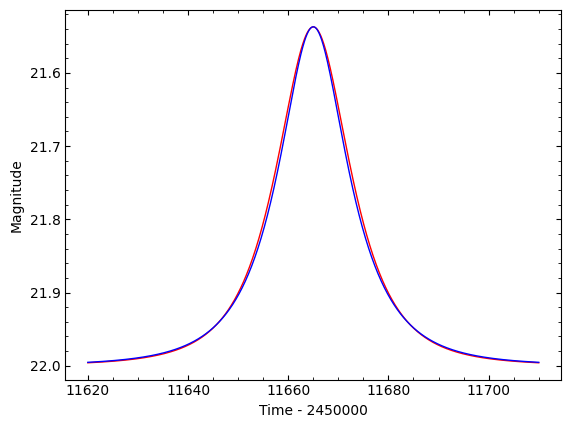

In [ ]:
# Comparison of the two different models. They look very similar!
event2 = mm.Event(datasets=pspl_mudata2hi, model=mm.Model({'t_0': truths2[0], 'u_0': truths2[1], 't_E': truths2[2]}))
event3 = mm.Event(datasets=pspl_mudata3hi, model=mm.Model({'t_0': truths3[0], 'u_0': truths3[1], 't_E': truths3[2]}))

event2.plot_model(subtract_2450000=True, color='r', t_range=[2450000 + 11620, 2450000 + 11710], lw=1)
event3.plot_model(subtract_2450000=True, color='b', t_range=[2450000 + 11620, 2450000 + 11710], lw=1)

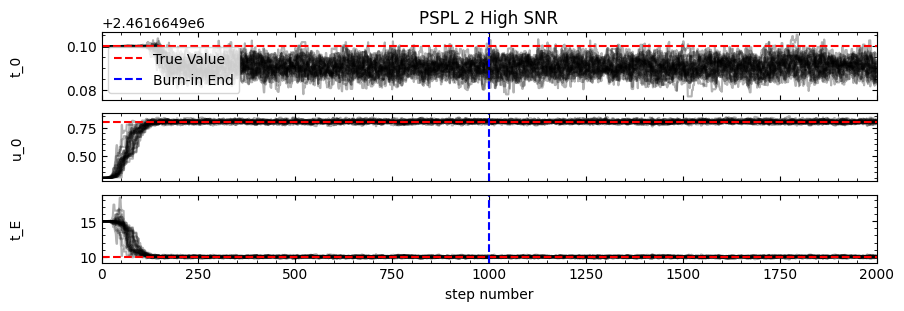

In [ ]:
fig, axes = plt.subplots(n_dim, 1, figsize=(10, 1 * n_dim), sharex=True)
for i in range(n_dim):
    ax = axes[i]
    ax.plot(samples2hi[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples2hi))
    ax.set_ylabel(parameters_to_fit[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.axhline(truths2[i], color='red', linestyle='--', label='True Value')
    ax.axvline(n_burn, color='blue', linestyle='--', label='Burn-in End')

axes[-1].set_xlabel("step number");
axes[0].legend()
axes[0].set_title('PSPL 2 High SNR')
plt.show()

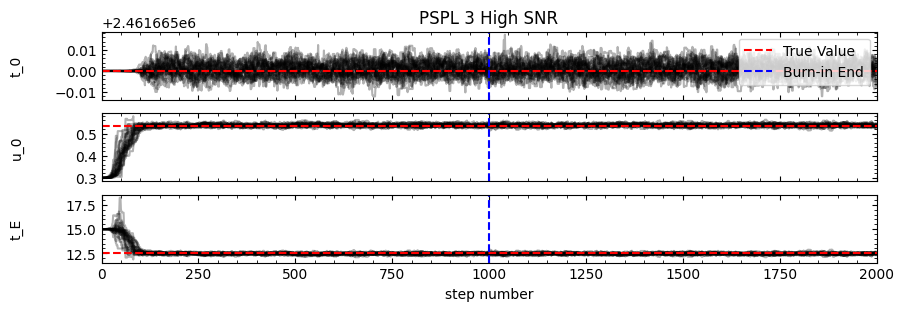

In [ ]:
fig, axes = plt.subplots(n_dim, 1, figsize=(10, 1 * n_dim), sharex=True)
for i in range(n_dim):
    ax = axes[i]
    ax.plot(samples3hi[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples3hi))
    ax.set_ylabel(parameters_to_fit[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.axhline(truths3[i], color='red', linestyle='--', label='True Value')
    ax.axvline(n_burn, color='blue', linestyle='--', label='Burn-in End')

axes[-1].set_xlabel("step number");
axes[0].legend()
axes[0].set_title('PSPL 3 High SNR')
plt.show()

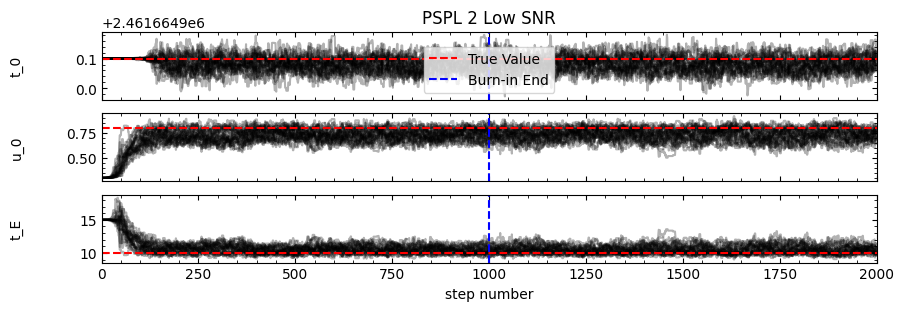

In [ ]:
fig, axes = plt.subplots(n_dim, 1, figsize=(10, 1 * n_dim), sharex=True)
for i in range(n_dim):
    ax = axes[i]
    ax.plot(samples2lo[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples2lo))
    ax.set_ylabel(parameters_to_fit[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.axhline(truths2[i], color='red', linestyle='--', label='True Value')
    ax.axvline(n_burn, color='blue', linestyle='--', label='Burn-in End')

axes[-1].set_xlabel("step number");
axes[0].legend()
axes[0].set_title('PSPL 2 Low SNR')
plt.show()

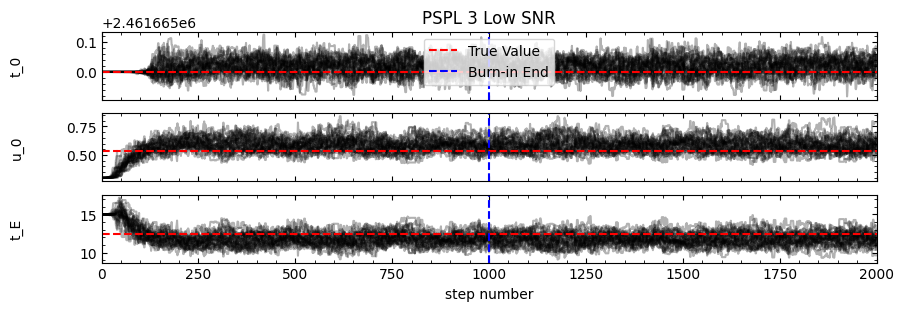

In [ ]:
fig, axes = plt.subplots(n_dim, 1, figsize=(10, 1 * n_dim), sharex=True)
for i in range(n_dim):
    ax = axes[i]
    ax.plot(samples3lo[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples3lo))
    ax.set_ylabel(parameters_to_fit[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.axhline(truths3[i], color='red', linestyle='--', label='True Value')
    ax.axvline(n_burn, color='blue', linestyle='--', label='Burn-in End')

axes[-1].set_xlabel("step number");
axes[0].legend()
axes[0].set_title('PSPL 3 Low SNR')
plt.show()

This shows the degeneracy between u0-tE-blend.

Microlensing throws around the word "degeneracy" a lot. To be clear, this can mean two different things. In one case, you have a "true" or "exact" degeneracy, where two models produce exactly the same lightcurve. For example, you can find different combinations of proper motion and lens mass that result in the exact same light curve.
The other kind of degeneracy is what is commonly refered to, where the data for whatever reason is insufficient to distinguish between two different models (e.g., noisy, gaps, systematic errors). This is because two models produce the same (or very similar lightcurves), within the observational errors.

The degeneracy is more severe (i.e., the best model is harder to distinguish) in lower SNR data.

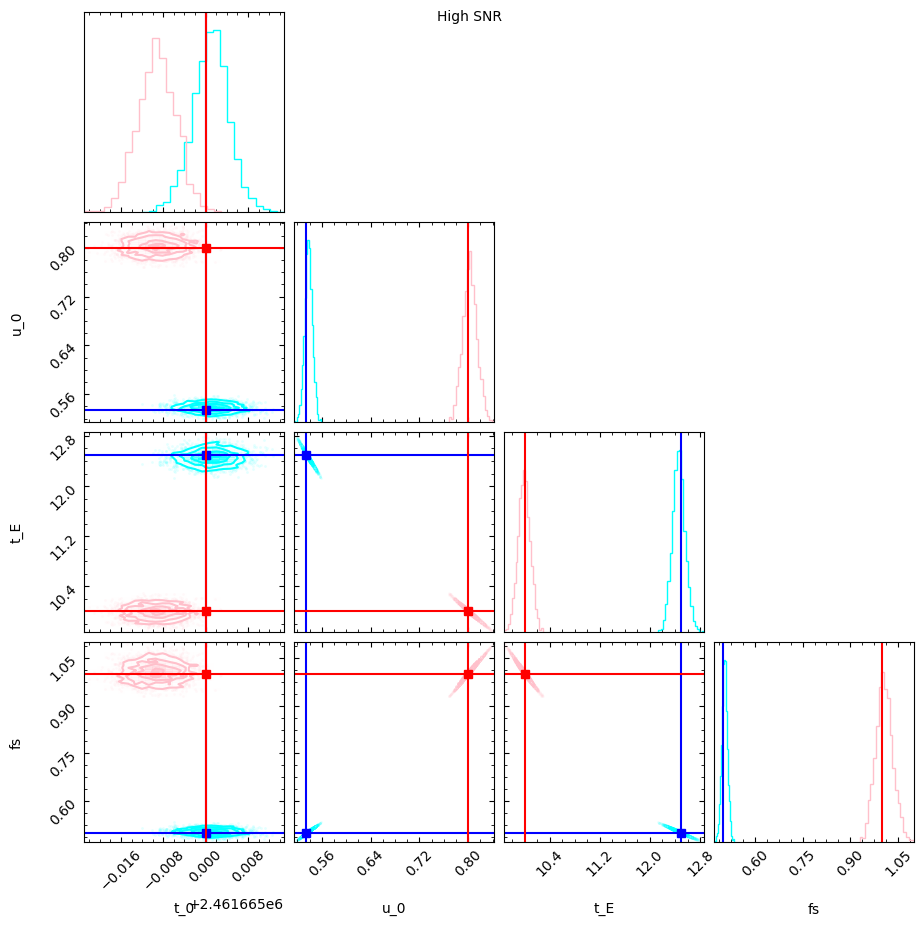

In [ ]:
fig = corner.corner(
    flat_samples3hi,
    labels=all_labels,
    errorbar=True,
    truth_color="blue",
    truths=truths3,
    hist_kwargs={'color': 'cyan'},
    color='cyan'
    )
corner.corner(
    flat_samples2hi,
    fig=fig,
    labels=all_labels,
    errorbar=True,
    truth_color="red",
    truths=truths2,
    hist_kwargs={'color': 'pink'},
    color='pink')
fig.text(0.5, 0.95, 'High SNR', ha='center')
plt.show()

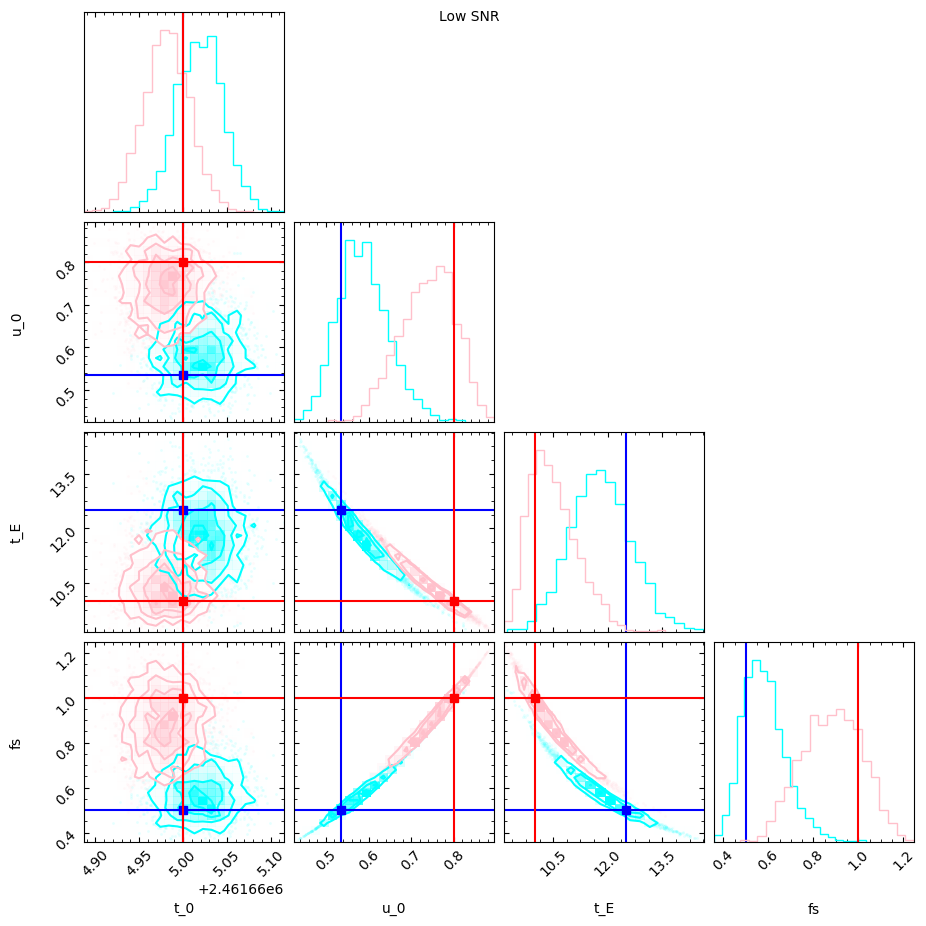

In [ ]:
fig = corner.corner(
    flat_samples3lo,
    labels=all_labels,
    errorbar=True,
    truth_color="blue",
    truths=truths3,
    hist_kwargs={'color': 'cyan'},
    color='cyan'
    )
corner.corner(
    flat_samples2lo,
    fig=fig,
    labels=all_labels,
    errorbar=True,
    truth_color="red",
    truths=truths2,
    hist_kwargs={'color': 'pink'},
    color='pink')
fig.text(0.5, 0.95, 'Low SNR', ha='center')
plt.show()